In [4]:
!pip install biopython
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

import urllib.request
import io
#from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
%pip install mrcfile

import mrcfile

%pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
%pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.5 MB/s eta 0:00:00


Téléchargement du fichier MRC...


Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=af945eb8-c3e4-4aed-882d-d9cc363673da
To: /content/map.mrc
100%|██████████| 228M/228M [00:08<00:00, 28.3MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)


Ouverture du fichier MRC...


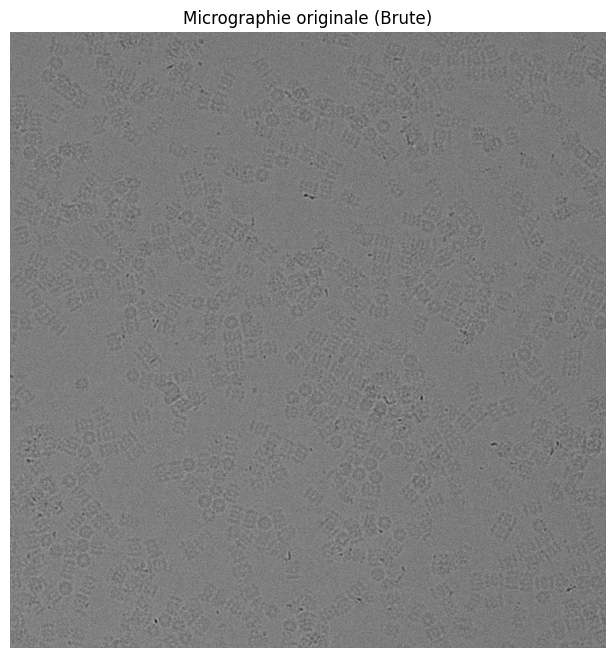

Format de l'image chargée : (7676, 7420)


In [5]:
import os
import gdown
import mrcfile
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. Téléchargement et chargement
# ==========================================
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output_file = "map.mrc"

# SI LE FICHIER EXISTE MAIS EST CORROMPU (trop petit), ON LE SUPPRIME
if os.path.exists(output_file) and os.path.getsize(output_file) < 1000:
    os.remove(output_file)

# Téléchargement propre
if not os.path.exists(output_file):
    print("Téléchargement du fichier MRC...")
    # On utilise fuzzy=True pour aider gdown avec les liens GDrive complexes
    gdown.download(id=file_id, output=output_file, quiet=False, fuzzy=True)

print("Ouverture du fichier MRC...")
with mrcfile.open(output_file, permissive=True) as mrc:
    raw_image = mrc.data.copy()

# On s'assure d'avoir une image 2D
image_2d = np.squeeze(raw_image)

# Calcul des percentiles pour l'affichage
vmin = np.percentile(image_2d, 5)
vmax = np.percentile(image_2d, 95)

# AFFICHAGE
plt.figure(figsize=(8, 8))
plt.imshow(image_2d, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Micrographie originale (Brute)")
plt.axis('off')
plt.show()

print(f"Format de l'image chargée : {image_2d.shape}")

étape 1 :

1- bining

-> Application d'un binning avec un facteur de 2...
Taille de l'image originale : (7676, 7420)
Taille de l'image binnée    : (3838, 3710)


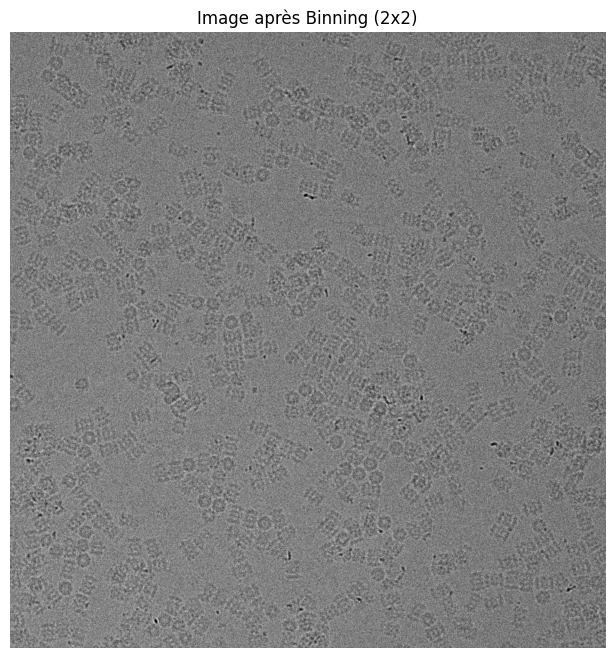

In [6]:


# ==========================================
# 1.1 Binning (Réduction de l'image)
# ==========================================

bin_factor = 2
print(f"-> Application d'un binning avec un facteur de {bin_factor}...")

print(f"Taille de l'image originale : {image_2d.shape}")

# J'utilise downscale_local_mean qui va faire la moyenne locale par blocs de 2x2 pixels
img_binned = transform.downscale_local_mean(image_2d, (bin_factor, bin_factor))

print(f"Taille de l'image binnée    : {img_binned.shape}")

# Affichage de contrôle pour vérifier qu'on voit toujours bien les particules
vmin = np.percentile(img_binned, 5)
vmax = np.percentile(img_binned, 95)

plt.figure(figsize=(8, 8))
plt.imshow(img_binned, cmap='gray', vmin=vmin, vmax=vmax)
plt.title(f"Image après Binning ({bin_factor}x{bin_factor})")
plt.axis('off')
plt.show()

2: Normalize the image

-> Début de la normalisation...
Avant - Moyenne : 16.03, Ecart-type : 2.08
Après - Moyenne : -0.00, Ecart-type : 1.00


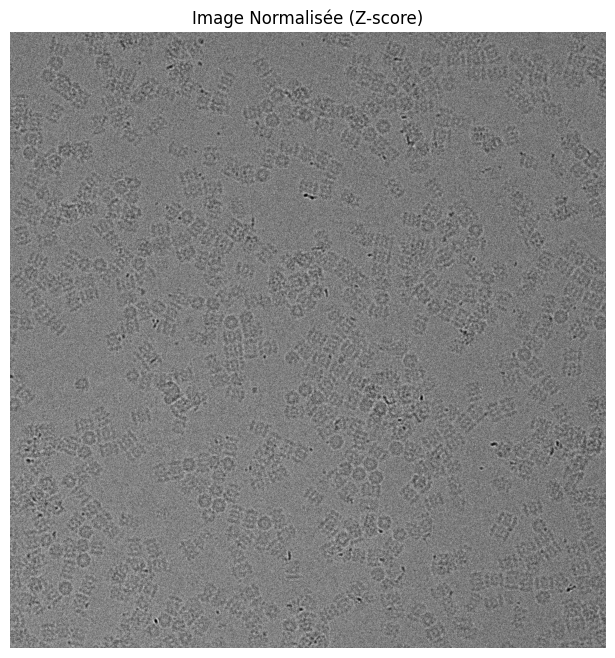

In [7]:
# ==========================================
# 1.2 Normalisation (Standardisation)
# ==========================================
# Je vais donc utiliser le Z-score pour ramener la moyenne de l'image à 0 et l'écart-type à 1.

print("-> Début de la normalisation...")

# 1. Je calcule les statistiques de mon image binnée
moyenne_avant = np.mean(img_binned)
ecart_type_avant = np.std(img_binned)

print(f"Avant - Moyenne : {moyenne_avant:.2f}, Ecart-type : {ecart_type_avant:.2f}")

# 2. J'applique la formule de standardisation à toute l'image
img_norm = (img_binned - moyenne_avant) / ecart_type_avant

# 3. Je vérifie que la transformation a bien fonctionné
moyenne_apres = np.mean(img_norm)
ecart_type_apres = np.std(img_norm)

# La moyenne après devrait être très proche de 0 (ex: 0.00) et l'écart-type à 1.00
print(f"Après - Moyenne : {moyenne_apres:.2f}, Ecart-type : {ecart_type_apres:.2f}")



# ==========================================
# Affichage de vérification
# ==========================================
vmin = np.percentile(img_norm, 5)
vmax = np.percentile(img_norm, 95)

plt.figure(figsize=(8, 8))
plt.imshow(img_norm, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Image Normalisée (Z-score)")
plt.axis('off')
plt.show()

3: Padding

-> Ajout d'une bordure de 100 pixels de chaque côté...
Taille avant : (3838, 3710)
Taille après : (4038, 3910)


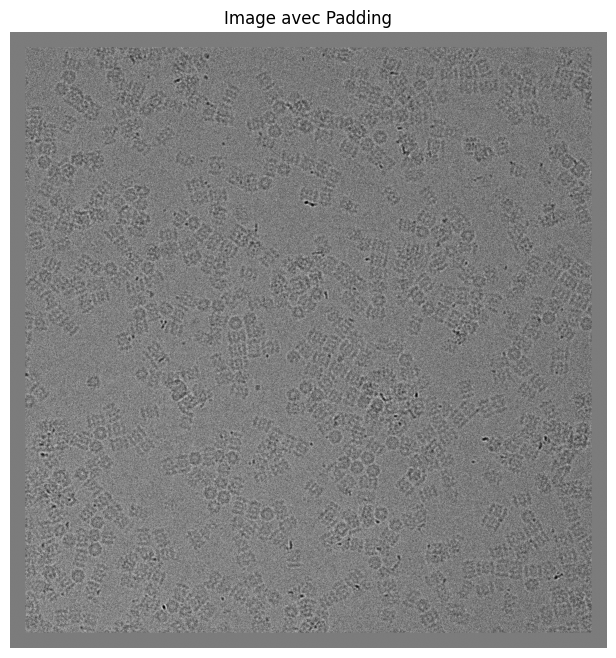

In [8]:
# ==========================================
# 1.3 Padding (Ajout de marges)
# ==========================================
# J'ajoute une bordure autour de l'image pour éviter les bugs (effets de bord)
# quand le modèle de recherche glissera sur les bords extrêmes de la micrographie.

pad_size = 100
print(f"-> Ajout d'une bordure de {pad_size} pixels de chaque côté...")

# J'utilise mode='constant' et constant_values=0.
# Comme l'image a été normalisée juste avant (moyenne = 0), ajouter des zéros
# correspond exactement à rajouter du "faux" bruit de fond neutre.
img_padded = np.pad(img_norm, pad_width=pad_size, mode='constant', constant_values=0)

print(f"Taille avant : {img_norm.shape}")
print(f"Taille après : {img_padded.shape}")

# Affichage du résultat pour vérifier que le cadre s'est bien ajouté
vmin = np.percentile(img_padded, 5)
vmax = np.percentile(img_padded, 95)

plt.figure(figsize=(8, 8))
plt.imshow(img_padded, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Image avec Padding")
plt.axis('off')
plt.show()

Chek the image format that the cc function accepts

-> Vérification du format avant le Template Matching...
Dimensions : 2D (Taille: (4038, 3910))
Type actuel : float32
Type après conversion : float32

=> L'étape 1 est terminée, l'image est prête !


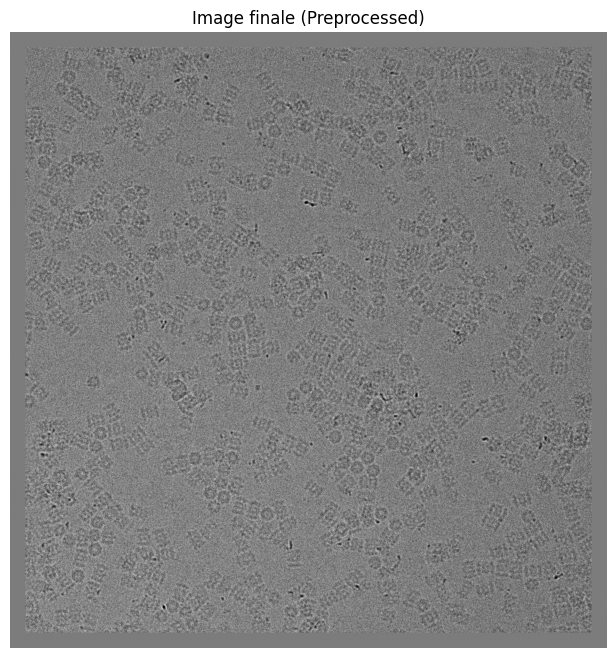

In [9]:
# ==========================================
# 1.4 Vérification du format final
# ==========================================
print("-> Vérification du format avant le Template Matching...")

# On vérifie les dimensions et le type de données actuel
print(f"Dimensions : {img_padded.ndim}D (Taille: {img_padded.shape})")
print(f"Type actuel : {img_padded.dtype}")

# Je force le passage en float32 pour être sûr que les fonctions de l'étape 3 ne plantent pas
img_final = img_padded.astype(np.float32)

print(f"Type après conversion : {img_final.dtype}")
print("\n=> L'étape 1 est terminée, l'image est prête !")

# Affichage final pour vérifier que tout est ok
vmin = np.percentile(img_final, 5)
vmax = np.percentile(img_final, 95)

plt.figure(figsize=(8, 8))
plt.imshow(img_final, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Image finale (Preprocessed)")
plt.axis('off')
plt.show()

optional : denoise (filtrer), crop the image to make a test image

-> Nettoyage de l'image de test ...
Taille de l'image de test : (512, 512)


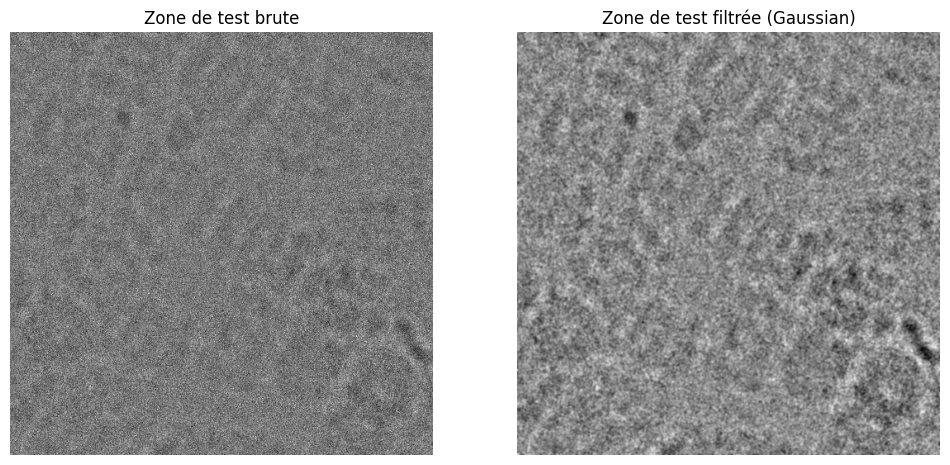

In [10]:
# ==========================================
# ÉTAPE OPTIONNELLE : Crop puis Denoise
# ==========================================
from skimage import filters


# 1. On découpe d'abord pour ne pas faire ramer l'ordi
h, w = img_final.shape
start_y, start_x = h//2, w//2
img_test_raw = img_final[start_y:start_y+512, start_x:start_x+512]

print("-> Nettoyage de l'image de test ...")

# 2. On applique un filtre Gaussien au lieu du Bilatéral
# Le sigma=1 permet de lisser juste ce qu'il faut pour le Template Matching
img_test = filters.gaussian(img_test_raw, sigma=1)

print(f"Taille de l'image de test : {img_test.shape}")

# 3. Affichage pour voir si c'est plus propre
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_test_raw, cmap='gray')
axes[0].set_title("Zone de test brute")
axes[0].axis('off')

axes[1].imshow(img_test, cmap='gray')
axes[1].set_title("Zone de test filtrée (Gaussian)")
axes[1].axis('off')

plt.show()

étape 2 : Prepare the template



1- Import the pdb



In [22]:

!pip install biopython

import os
import urllib.request
from Bio.PDB import PDBParser

# ==========================================
# ÉTAPE 2.1 : Importation du modèle PDB
# ==========================================
# Le PDB contient les coordonnées 3D de tous les atomes de notre protéine.
# C'est lui qui va nous servir de modèle (template) de recherche.
# Au lieu de le télécharger à la main, je le récupère directement depuis la banque PDB.

pdb_id = "6BDF"  # <--- REMPLACE ICI PAR LE CODE DE TA PROTÉINE (ex: "6VXX")
pdb_file = f"{pdb_id}.pdb"

print(f"-> Récupération de la structure {pdb_id.upper()}...")

# 1. Téléchargement automatique (uniquement si on ne l'a pas déjà)
if not os.path.exists(pdb_file):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    try:
        urllib.request.urlretrieve(url, pdb_file)
        print("Téléchargement terminé !")
    except Exception as e:
        print(f"Erreur de téléchargement : Vérifie que l'ID {pdb_id} existe bien.")
else:
    print("Le fichier PDB est déjà présent dans les dossiers.")

# 2. Lecture et vérification du PDB avec Biopython
print("-> Analyse du fichier PDB...")
# J'utilise QUIET=True pour cacher les petits avertissements sans importance de Biopython
parser = PDBParser(QUIET=True)

try:
    structure = parser.get_structure(pdb_id, pdb_file)

    # Je compte les atomes pour vérifier que le fichier n'est pas vide
    nb_atomes = len(list(structure.get_atoms()))

    print("Succès ! Structure chargée.")
    print(f"Nombre total d'atomes trouvés : {nb_atomes}")

except FileNotFoundError:
    print("Le fichier n'a pas été trouvé, le téléchargement a dû échouer.")

-> Récupération de la structure 6BDF...
Téléchargement terminé !
-> Analyse du fichier PDB...
Succès ! Structure chargée.
Nombre total d'atomes trouvés : 46382


-> Taille de la boîte générée : 72x72 pixels


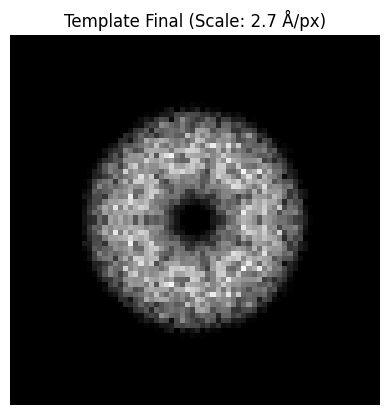

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Préparation des coordonnées (Modèle 6BDF)
coords = np.array([atom.get_coord() for atom in structure.get_atoms()])
coords -= coords.mean(axis=0) # Centrage

# 2. Paramètres d'échelle validés
pixel_size = 2.70  # Å/pixel (Valeur calculée : 1.35 * 2)
marge = 30         # Ångströms de sécurité

# 3. Calcul de la taille de la boîte (Box Size)
diametre = np.max(coords) - np.min(coords)
box_size = int((diametre + marge) / pixel_size)
print(f"-> Taille de la boîte générée : {box_size}x{box_size} pixels")

# 4. Projection par histogramme 2D
limite = (box_size * pixel_size) / 2
template_data, _, _ = np.histogram2d(
    coords[:, 0], coords[:, 1],
    bins=box_size,
    range=[[-limite, limite], [-limite, limite]]
)

# 5. Normalisation et formatage (Indispensable pour la NCC)
template_final = (template_data.T / template_data.max()).astype(np.float32)

# Affichage du résultat
plt.imshow(template_final, cmap='gray', origin='lower')
plt.title(f"Template Final (Scale: {pixel_size} Å/px)")
plt.axis('off')
plt.show()

2- Make projections (check pixel sixe (if px size matches the dimensions will match just need to choose box size in which particle will fit), normalization, image format)

-> Template généré : 72x72 pixels
-> Stats Z-score : Moyenne = 0.00, Écart-type = 1.00


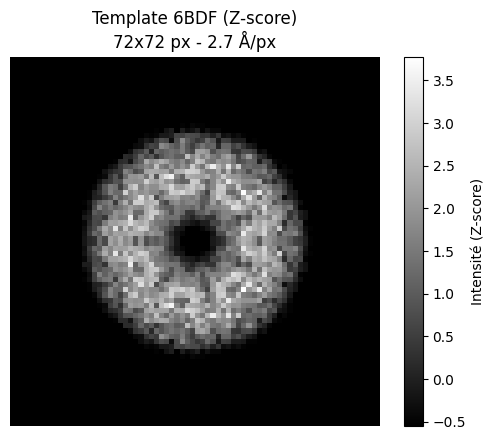

In [45]:
# ==========================================
# ÉTAPE 2.2 : Génération du Template (Version Finale)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

coords = np.array([atom.get_coord() for atom in structure.get_atoms()])
coords -= coords.mean(axis=0)

# 2. Paramètres d'échelle et de boîte
pixel_size = 2.70  # Å/pixel (1.35 microscope * binning 2)
marge = 30         # Padding de sécurité en Å
diametre = np.max(coords) - np.min(coords)
box_size = int((diametre + marge) / pixel_size)

# 3. Projection 2D par histogramme
limite = (box_size * pixel_size) / 2
template_raw, _, _ = np.histogram2d(
    coords[:, 0], coords[:, 1],
    bins=box_size,
    range=[[-limite, limite], [-limite, limite]]
)

# 4. NORMALISATION Z-SCORE (Indispensable pour la NCC)
# On transforme les données pour avoir une moyenne de 0 et un écart-type de 1
moyenne = np.mean(template_raw)
std = np.std(template_raw)
template_zscore = (template_raw - moyenne) / (std + 1e-10)

# 5. Formatage final
template_final = template_zscore.T.astype(np.float32)

print(f"-> Template généré : {box_size}x{box_size} pixels")
print(f"-> Stats Z-score : Moyenne = {template_final.mean():.2f}, Écart-type = {template_final.std():.2f}")

# Affichage
plt.imshow(template_final, cmap='gray', origin='lower')
plt.title(f"Template 6BDF (Z-score)\n{box_size}x{box_size} px - {pixel_size} Å/px")
plt.colorbar(label="Intensité (Z-score)")
plt.axis('off')
plt.show()

Boîte générée : 180x180 px


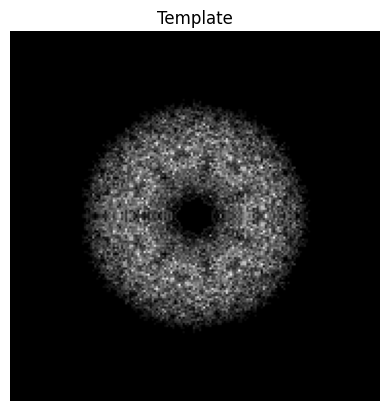

In [30]:
# ==========================================
# ÉTAPE 2.2 : Création des projections (Le Template)
# ==========================================
# Je crée la projection 2D à partir du modèle 3D.
# POINT CRITIQUE : Il faut que l'échelle du template (Å/pixel) soit exactement
# la même que celle de la micrographie pour que le matching fonctionne.

import numpy as np
import matplotlib.pyplot as plt

# 1. Coordonnées de la protéine
coords = np.array([atom.get_coord() for atom in structure.get_atoms()])
coords -= coords.mean(axis=0) # Centrage sur zéro

# 2. Taille de pixel et Box Size
pixel_size = 1.08  # Å/pixel (Valeur de référence)
diametre = np.max(coords) - np.min(coords)
box_size = int((diametre + 30) / pixel_size) # 30 Å de marge
print(f"Boîte générée : {box_size}x{box_size} px")

# 3. Projection 2D (Histogramme)
limite = (box_size * pixel_size) / 2
template, _, _ = np.histogram2d(
    coords[:, 0], coords[:, 1],
    bins=box_size,
    range=[[-limite, limite], [-limite, limite]]
)

# 4. Normalisation (entre 0 et 1) et format (float32)
template_final = (template.T / template.max()).astype(np.float32)

# Affichage simple
plt.imshow(template_final, cmap='gray', origin='lower')
plt.title("Template")
plt.axis('off')
plt.show()

Bonus- add noise

-> Simulation des conditions réelles (Ajout de bruit)...


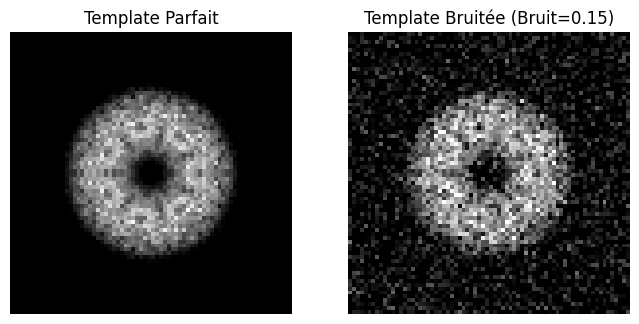

In [37]:
# ==========================================
# ÉTAPE 2.3 (Optionnelle) : Ajout de bruit artificiel
# ==========================================
# Le vrai signal en cryo-ME est très faible. J'ajoute un bruit gaussien
# pour rendre mon template plus "réaliste".

print("-> Simulation des conditions réelles (Ajout de bruit)...")

# 1. Je génère un bruit aléatoire
niveau_de_bruit = 0.15
bruit = np.random.normal(loc=0.0, scale=niveau_de_bruit, size=template_final.shape)

# 2. J'ajoute le bruit à l'image et je "coupe" (clip) ce qui dépasse de 0 ou 1
template_bruit = np.clip(template_final + bruit, 0, 1).astype(np.float32)

# 3. Affichage comparatif (Parfait vs Réaliste)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(template_final, cmap='gray', origin='lower')
axes[0].set_title("Template Parfait")
axes[0].axis('off')

axes[1].imshow(template_bruit, cmap='gray', origin='lower')
axes[1].set_title(f"Template Bruitée (Bruit={niveau_de_bruit})")
axes[1].axis('off')

plt.show()

étape 3 : NCC



1-Optimize the shift.


-> 1. Calcul de la NCC en cours (balayage X, Y)...
-> NCC terminée ! Extraction des meilleures positions...
Nombre de particules candidates trouvées : 211


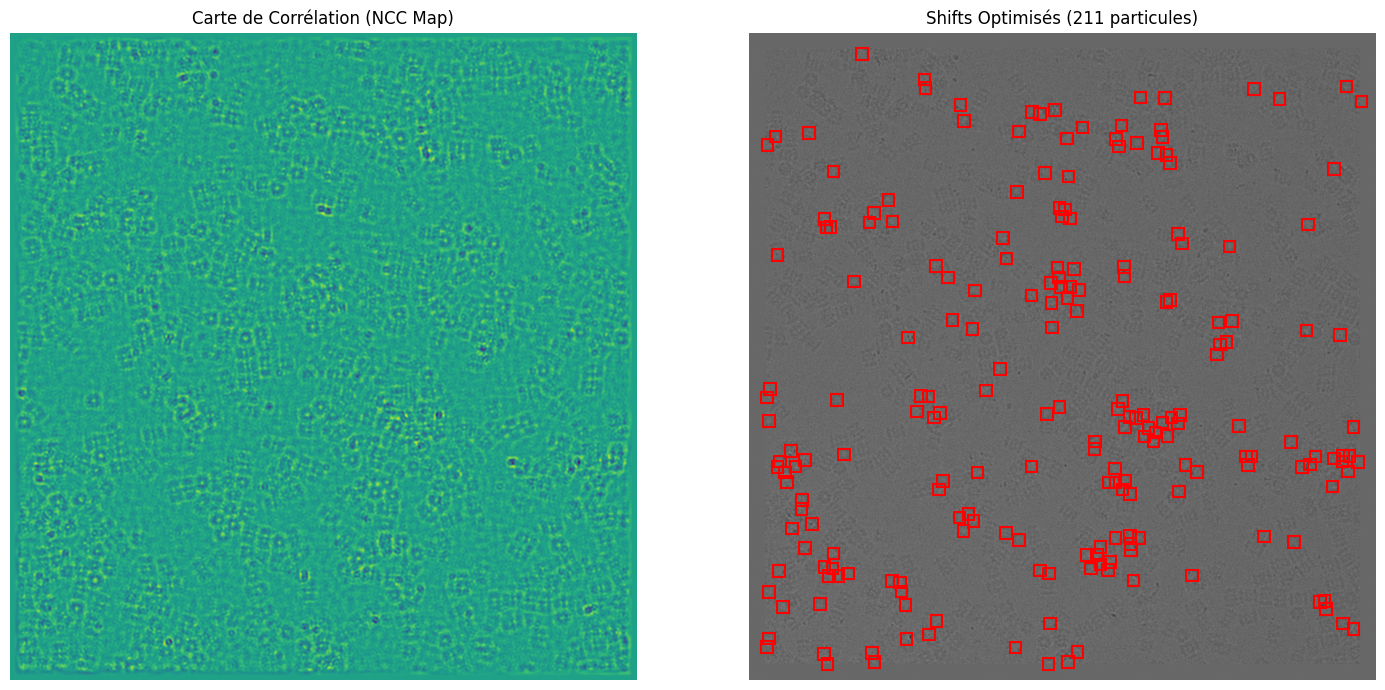

In [38]:
# ==========================================
# ÉTAPE 3 : Normalized Cross-Correlation (NCC)
# ==========================================
from skimage.feature import match_template, peak_local_max
import matplotlib.patches as patches


image_cible = img_final

print("-> 1. Calcul de la NCC en cours (balayage X, Y)...")

# La fonction match_template fait glisser le modèle partout et calcule le score de 0 à 1
resultat_ncc = match_template(image_cible, template_final)

print("-> NCC terminée ! Extraction des meilleures positions...")

# -> 2. Optimisation du shift (Recherche des pics)
# On extrait les coordonnées (X, Y) où le score NCC est le plus fort.
# - min_distance : empêche d'avoir 2 détections collées l'une à l'autre (ex: 20 pixels d'écart min)
# - threshold_rel : On garde les pics qui atteignent au moins 60% (0.6) du score maximum trouvé
coordonnees_pics = peak_local_max(resultat_ncc, min_distance=20, threshold_rel=0.6)

print(f"Nombre de particules candidates trouvées : {len(coordonnees_pics)}")

# ==========================================
# 3. Affichage des Résultats
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# A) Affichage de la carte de chaleur (Score de corrélation)
# Plus c'est jaune, plus le score NCC est proche de 1
axes[0].imshow(resultat_ncc, cmap='viridis')
axes[0].set_title("Carte de Corrélation (NCC Map)")
axes[0].axis('off')

# B) Affichage des particules trouvées sur l'image d'origine
axes[1].imshow(image_cible, cmap='gray')
axes[1].set_title(f"Shifts Optimisés ({len(coordonnees_pics)} particules)")
axes[1].axis('off')

# On dessine un carré rouge autour de chaque particule détectée
h_temp, w_temp = template_final.shape

for y, x in coordonnees_pics:
    # Dans match_template, (x,y) correspond au coin en haut à gauche du template
    rect = patches.Rectangle((x, y), w_temp, h_temp, linewidth=1.5, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)

plt.tight_layout()
plt.show()

2- optimize the threshold

-> Test de différents seuils pour la détection...


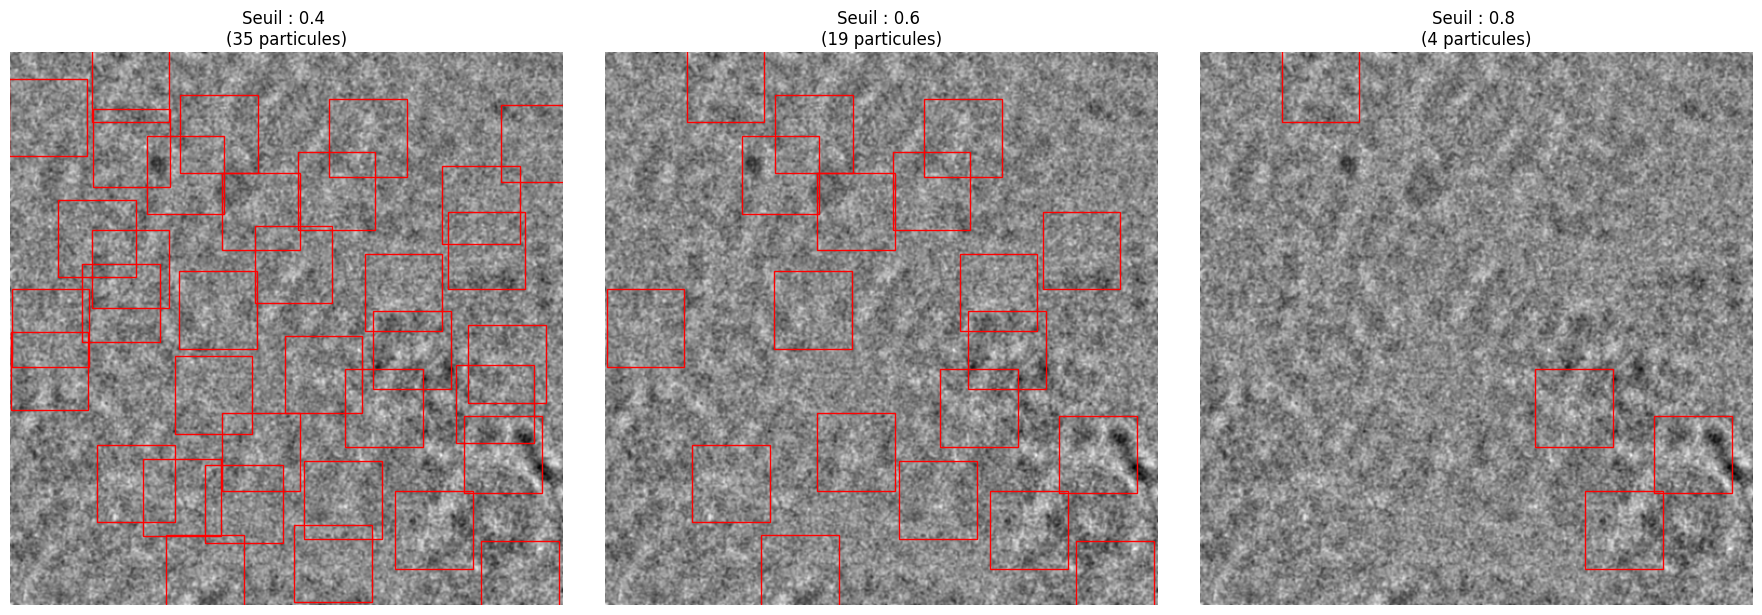


=> Conclusion : Le seuil optimal retenu est 0.6.
=> Nombre de particules de complexe détectées : 19


In [42]:
# ==========================================
# ÉTAPE 3.1 : Optimisation du Seuil
# ==========================================
# Je teste plusieurs seuils de corrélation pour trouver le meilleur compromis

# ==========================================
# ÉTAPE 3.1 : Optimisation du Seuil
# ==========================================
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
import matplotlib.patches as patches


print("-> Test de différents seuils pour la détection...")

# Seuils à comparer (Laxiste, Moyen, Strict)
seuils_a_tester = [0.4, 0.6, 0.8]

# Préparation de l'affichage
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
h_temp, w_temp = template_final.shape

# On utilise 'carte_max' si on a fait la rotation (Étape 3.2),
# ou 'resultat_ncc' pour un scan sans rotation.
source_donnees = carte_max

for i, seuil in enumerate(seuils_a_tester):

    # 1. Extraction des pics pour ce seuil spécifique
    pics_test = peak_local_max(source_donnees, min_distance=20, threshold_rel=seuil)

    # 2. Affichage de l'image
    axes[i].imshow(img_test, cmap='gray')
    axes[i].set_title(f"Seuil : {seuil} \n({len(pics_test)} particules)")
    axes[i].axis('off')

    # 3. Dessin des boîtes (centrées sur le pic)
    for y, x in pics_test:
        # On retire la moitié de la taille pour que le pic soit au centre du carré
        rect = patches.Rectangle((x - w_temp/2, y - h_temp/2), w_temp, h_temp,
                                 linewidth=1, edgecolor='red', facecolor='none')
        axes[i].add_patch(rect)

plt.tight_layout()
plt.show()

# ==========================================
# Sélection finale
# ==========================================
seuil_optimal = 0.6
pics_finaux = peak_local_max(source_donnees, min_distance=20, threshold_rel=seuil_optimal)

print(f"\n=> Conclusion : Le seuil optimal retenu est {seuil_optimal}.")
print(f"=> Nombre de particules de complexe détectées : {len(pics_finaux)}")

3- optimize if working with side view optimize the angle step

-> Initialisation de la recherche angulaire...
Nombre d'angles à tester : 24 (par pas de 15°)
-> Recherche terminée ! Extraction des particules...
Particules trouvées : 40


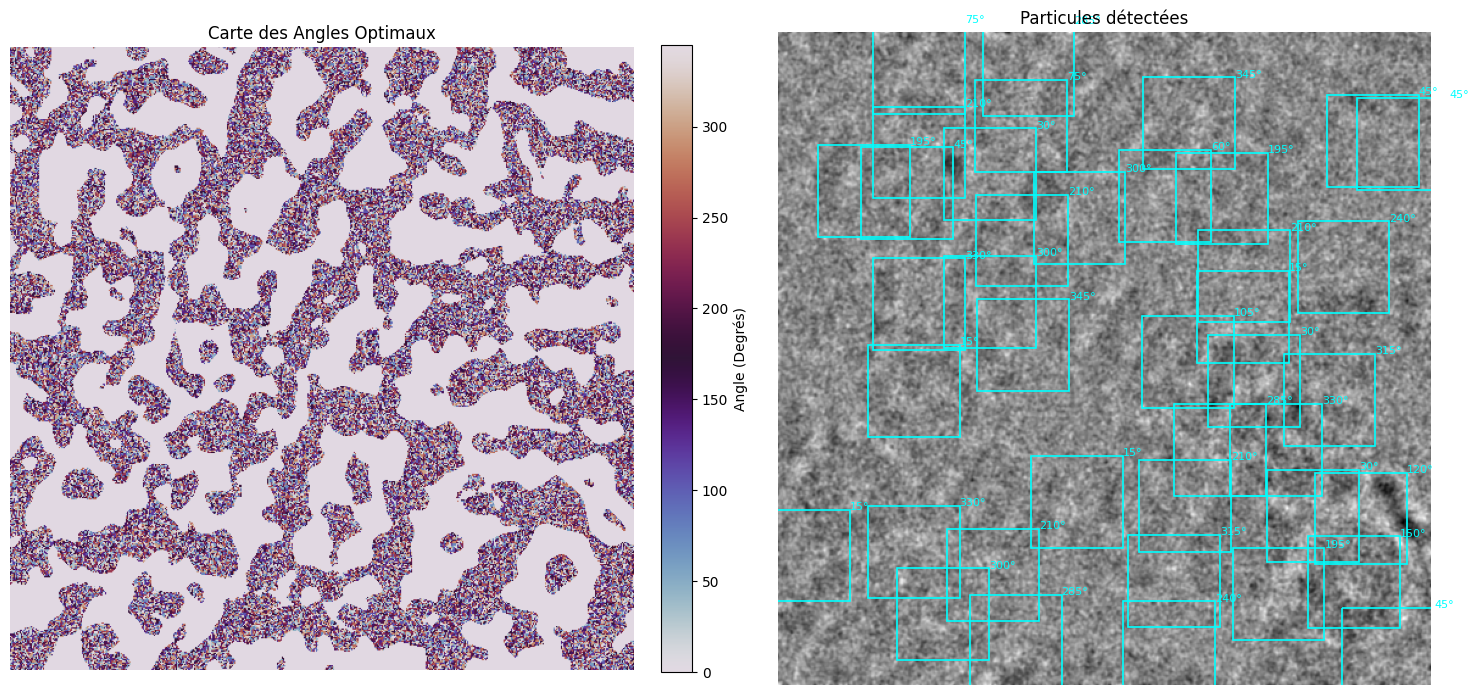

In [44]:
# ==========================================
# ÉTAPE 3.2 : NCC avec Recherche Angulaire (Rotation)
# ==========================================
from skimage.transform import rotate
from skimage.feature import match_template, peak_local_max
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np


image_cible = img_test


template_a_tourner = template_final

print("-> Initialisation de la recherche angulaire...")

#OPTIMISATION DU PAS ANGULAIRE
angle_step = 15
angles_a_tester = np.arange(0, 360, angle_step)

print(f"Nombre d'angles à tester : {len(angles_a_tester)} (par pas de {angle_step}°)")

carte_max_ncc = np.zeros_like(image_cible, dtype=np.float32)
carte_meilleur_angle = np.zeros_like(image_cible, dtype=np.float32)

# --- BOUCLE DE ROTATION ---
for angle in angles_a_tester:
    # On tourne le template
    temp_rot = rotate(template_a_tourner, angle, resize=False)

    # On calcule la NCC (pad_input=True pour garder les coordonnées centrées)
    ncc_angle = match_template(image_cible, temp_rot, pad_input=True)

    # Mise à jour de la carte des maximums
    masque_amelioration = ncc_angle > carte_max_ncc
    carte_max_ncc[masque_amelioration] = ncc_angle[masque_amelioration]
    carte_meilleur_angle[masque_amelioration] = angle

print("-> Recherche terminée ! Extraction des particules...")

# extraction et affichage
seuil = 0.6
pics_orientes = peak_local_max(carte_max_ncc, min_distance=20, threshold_rel=seuil)

print(f"Particules trouvées : {len(pics_orientes)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im_angles = axes[0].imshow(carte_meilleur_angle, cmap='twilight')
axes[0].set_title(f"Carte des Angles Optimaux")
axes[0].axis('off')
plt.colorbar(im_angles, ax=axes[0], fraction=0.046, pad=0.04, label="Angle (Degrés)")

axes[1].imshow(image_cible, cmap='gray')
axes[1].set_title(f"Particules détectées")
axes[1].axis('off')

h_temp, w_temp = template_a_tourner.shape

for y, x in pics_orientes:
    angle_match = carte_meilleur_angle[y, x]

    rect = patches.Rectangle((x - w_temp/2, y - h_temp/2), w_temp, h_temp,
                             linewidth=1.2, edgecolor='cyan', facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(x + w_temp/2, y - h_temp/2, f"{int(angle_match)}°", color='cyan', fontsize=8)

plt.tight_layout()
plt.show()